## Feature Correlation Analysis

> **Why analyze feature correlations?**
>
> Feature correlation analysis serves two purposes in CTR prediction:
>
> 1. **Identify redundancy**: Highly correlated features (|r| > 0.8) carry similar
>    information. Including both wastes embedding parameters without adding signal.
>
> 2. **Guide feature crossing**: Moderately correlated features (0.3 < |r| < 0.7)
>    are prime candidates for explicit feature crossing — their interaction captures
>    non-linear patterns that individual features miss. This is exactly what DeepFM's
>    FM component and DCN's cross layers aim to learn.
>
> **How it works**: Pearson correlation measures linear association between two variables.
> Values range from -1 (perfect negative) to +1 (perfect positive). We compute this
> pairwise for all numerical features and visualize as a heatmap.

In [ ]:
# Feature Correlation Analysis
# Why: Correlated features indicate redundancy (waste of parameters) and
# suggest which features might benefit from explicit crossing.
# How: We compute pairwise Pearson correlation between numerical features.

if 'train_df' in dir():
    num_cols = [c for c in train_df.columns if c.startswith('I')]
    corr_matrix = train_df[num_cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, ax=ax, square=True)
    ax.set_title('Numerical Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()

    # Find highly correlated pairs
    high_corr = []
    for j in range(len(num_cols)):
        for k in range(j+1, len(num_cols)):
            r = abs(corr_matrix.iloc[j, k])
            if r > 0.5:
                high_corr.append((num_cols[j], num_cols[k], corr_matrix.iloc[j, k]))

    if high_corr:
        print('Highly correlated feature pairs (|r| > 0.5):')
        for f1, f2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
            print(f'  {f1} <-> {f2}: r = {r:.3f}')
        print('\nThese pairs are candidates for feature crossing in DeepFM/DCN.')
    else:
        print('No highly correlated pairs found — features are relatively independent.')

# Criteo Dataset Exploration & Feature Engineering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo/rec_system_experimental/blob/main/notebooks/01_criteo_feature_crossing/01_data_exploration.ipynb)
[![Download Notebook](https://img.shields.io/badge/Download-Notebook-blue)](./01_data_exploration.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand** the Criteo Display Advertising Challenge dataset structure and characteristics
2. **Perform** comprehensive exploratory data analysis (EDA) on large-scale CTR prediction data
3. **Identify** key challenges: high cardinality, missing values, skewed distributions
4. **Apply** feature engineering techniques tailored for deep CTR models (DeepFM, DCN)
5. **Prepare** the dataset for downstream model training

## Prerequisites

- Basic understanding of click-through rate (CTR) prediction
- Familiarity with pandas, matplotlib, and scikit-learn
- The Criteo dataset (`train.txt`) placed in `../../data/criteo/`

## Table of Contents

1. [Setup & Configuration](#1-setup--configuration)
2. [Data Loading](#2-data-loading)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Save Processed Data](#5-save-processed-data)
6. [Exercises](#6-exercises)
7. [Summary & Key Takeaways](#7-summary--key-takeaways)

## Dataset Background & Task Definition

> **Why CTR Prediction?**
>
> Click-Through Rate (CTR) prediction is the backbone of online advertising. When a user
> visits a webpage, an ad auction determines which ads to show. The system must predict
> the probability that the user will click each candidate ad. Accurate CTR prediction
> directly impacts:
> - **Revenue**: Advertisers pay per click (CPC model), so accurate CTR = accurate revenue estimation
> - **User experience**: Showing relevant ads reduces ad fatigue
> - **Advertiser ROI**: Better predictions mean better budget allocation

### Column Descriptions

The Criteo dataset contains **anonymized** ad click logs. Each row is one ad impression:

| Column | Name | Type | Description |
|--------|------|------|-------------|
| Label | — | Binary (0/1) | 1 = user clicked the ad, 0 = not clicked |
| I1-I13 | Numerical features | Float | 13 anonymized numerical features (e.g., ad position, page depth, historical CTR). Values are real-valued and may contain missing entries. |
| C1-C26 | Categorical features | String (hashed) | 26 anonymized categorical features (e.g., ad category, device type, publisher domain, user segment). Values are 32-bit hashed strings. |

> **Why are features anonymized?**
>
> Criteo anonymizes features to protect advertiser privacy and prevent reverse-engineering
> of their ad serving logic. While this limits interpretability, it makes the dataset
> safe for public research. The anonymization does NOT affect model training — models
> learn feature interactions regardless of semantic meaning.

### What We Will Analyze and Why

| Analysis | Why It Matters |
|----------|---------------|
| **Class balance** | Imbalanced CTR (~26%) affects loss function choice and threshold tuning |
| **Missing values** | Many features have missing values — we need imputation strategies before modeling |
| **Feature distributions** | Skewed distributions benefit from log transforms; helps choose embedding dims |
| **Feature cardinality** | High-cardinality categoricals need embeddings (not one-hot); determines embedding table sizes |
| **Feature correlations** | Redundant features waste parameters; correlated features inform feature crossing strategy |

## 1. Setup & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, log_loss
import warnings
import os
import pickle

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plotting configuration
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')

# Dataset configuration
DATA_PATH = '../../data/criteo/dac/train.txt'
SAMPLE_SIZE = 1_000_000  # Use first 1M rows for tutorial speed
NUM_FEATURES = [f'I{i}' for i in range(1, 14)]  # I1-I13
CAT_FEATURES = [f'C{i}' for i in range(1, 27)]  # C1-C26
ALL_COLUMNS = ['label'] + NUM_FEATURES + CAT_FEATURES

# Output directory for processed data
PROCESSED_DIR = '../../data/criteo/processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

print(f'Number of numerical features: {len(NUM_FEATURES)}')
print(f'Number of categorical features: {len(CAT_FEATURES)}')
print(f'Total columns: {len(ALL_COLUMNS)}')

Number of numerical features: 13
Number of categorical features: 26
Total columns: 40


## 2. Data Loading

> **Concept:** The Criteo dataset is one of the most widely-used benchmarks for CTR prediction.
> It contains ~45 million ad impression records with 13 integer features (I1-I13) and
> 26 categorical features (C1-C26) stored as hashed hexadecimal strings. The file is
> tab-separated with no header row.

We load only the first 1M rows to keep training times manageable in a tutorial setting.
In production, you would use the full dataset or a much larger sample.

In [2]:
print(f'Loading first {SAMPLE_SIZE:,} rows from {DATA_PATH}...')

df = pd.read_csv(
    DATA_PATH,
    sep='\t',
    header=None,
    names=ALL_COLUMNS,
    nrows=SAMPLE_SIZE
)

print(f'Dataset shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Loading first 1,000,000 rows from ../../data/criteo/dac/train.txt...


Dataset shape: (1000000, 40)
Memory usage: 505.4 MB


,label,I1,I2,I3,I4,I5,I6,I7,I8,I9,...,C17,C18,C19,C20,C21,C22,C23,C24,C25,C26
0,0,1.0,1,5.0,0.0,1382.0,4.0,15.0,2.0,181.0,...,e5ba7672,f54016b9,21ddcdc9,b1252a9d,07b5194c,NaN,3a171ecb,c5c50484,e8b83407,9727dd16
1,0,2.0,0,44.0,1.0,102.0,8.0,2.0,2.0,4.0,...,07c540c4,b04e4670,21ddcdc9,5840adea,60f6221e,NaN,3a171ecb,43f13e8b,e8b83407,731c3655
2,0,2.0,0,1.0,14.0,767.0,89.0,4.0,2.0,245.0,...,8efede7f,3412118d,NaN,NaN,e587c466,ad3062eb,3a171ecb,3b183c5c,NaN,NaN
3,0,NaN,893,NaN,NaN,4392.0,NaN,0.0,0.0,0.0,...,1e88c74f,74ef3502,NaN,NaN,6b3a5ca6,NaN,3a171ecb,9117a34a,NaN,NaN
4,0,3.0,-1,NaN,0.0,2.0,0.0,3.0,0.0,0.0,...,1e88c74f,26b3c7a7,NaN,NaN,21c9516a,NaN,32c7478e,b34f3128,NaN,NaN


In [3]:
print('Data types:')
print(df.dtypes.value_counts())
print()
print('Basic statistics for numerical features:')
df[NUM_FEATURES].describe()

Data types:
str        26
float64    12
int64       2
Name: count, dtype: int64

Basic statistics for numerical features:


,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13
count,576997.000000,1000000.000000,764946.000000,750884.000000,9.754640e+05,778260.000000,959166.000000,999338.000000,959166.000000,576997.000000,959166.000000,229943.000000,750884.000000
mean,3.238400,93.965184,21.094269,6.954270,1.861653e+04,116.761653,14.592224,13.378894,105.450931,0.572658,2.507449,0.979991,7.630003
std,8.944151,349.884675,344.010001,8.554014,6.768665e+04,456.056847,58.277459,32.345836,217.405401,0.679937,4.825370,6.003874,35.071487
min,0.000000,-2.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000,2.000000,8.290000e+02,8.000000,1.000000,2.000000,10.000000,0.000000,0.000000,0.000000,2.000000
50%,1.000000,2.000000,5.000000,4.000000,2.548000e+03,33.000000,3.000000,8.000000,39.000000,0.000000,1.000000,0.000000,4.000000
75%,3.000000,32.000000,14.000000,9.000000,1.016300e+04,102.000000,11.000000,20.000000,110.000000,1.000000,3.000000,0.000000,9.000000
max,780.000000,18522.000000,65535.000000,507.000000,2.527030e+06,233523.000000,8807.000000,5064.000000,19327.000000,8.000000,147.000000,768.000000,6702.000000


## 3. Exploratory Data Analysis

### 3.1 Click-Through Rate Distribution

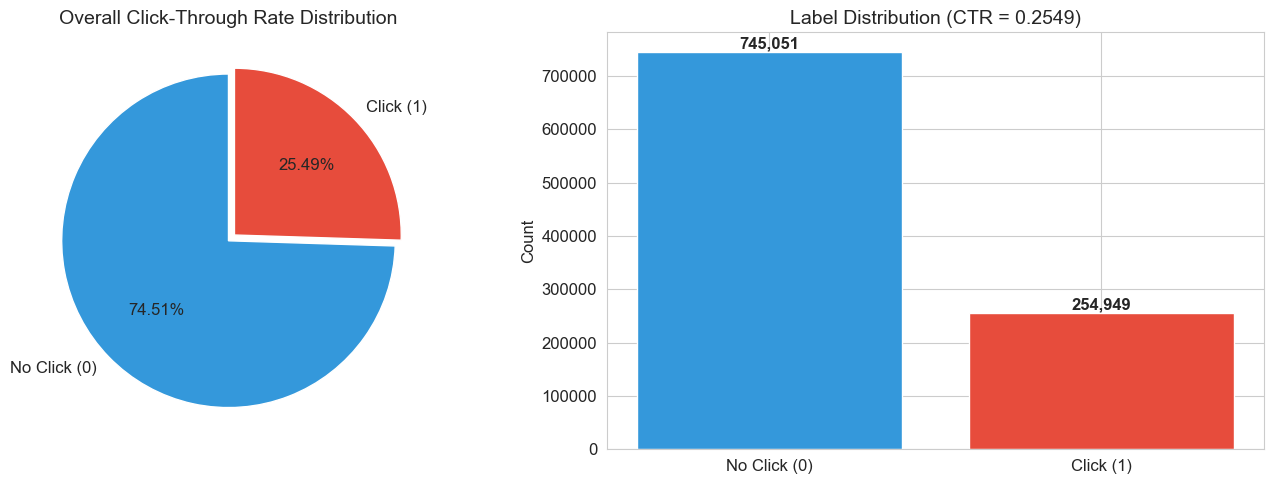

Overall CTR: 0.2549 (25.49%)
Click count: 254,949
No-click count: 745,051


In [4]:
# Fig 1: Overall CTR pie chart
ctr = df['label'].mean()
counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(
    counts.values,
    labels=['No Click (0)', 'Click (1)'],
    autopct='%1.2f%%',
    colors=['#3498db', '#e74c3c'],
    startangle=90,
    explode=(0, 0.05)
)
axes[0].set_title('Overall Click-Through Rate Distribution')

# Bar chart
axes[1].bar(['No Click (0)', 'Click (1)'], counts.values, color=['#3498db', '#e74c3c'])
axes[1].set_ylabel('Count')
axes[1].set_title(f'Label Distribution (CTR = {ctr:.4f})')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + counts.values.max() * 0.01, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_ctr_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall CTR: {ctr:.4f} ({ctr*100:.2f}%)')
print(f'Click count: {counts[1]:,}')
print(f'No-click count: {counts[0]:,}')

> **Common Pitfall:** The Criteo dataset has a significant class imbalance (~26% positive).
> While not as extreme as some CTR datasets (which can have <1% CTR), you should still
> be aware that metrics like accuracy can be misleading. Always use AUC and LogLoss
> as your primary evaluation metrics for CTR prediction.

### 3.2 Numerical Feature Distributions

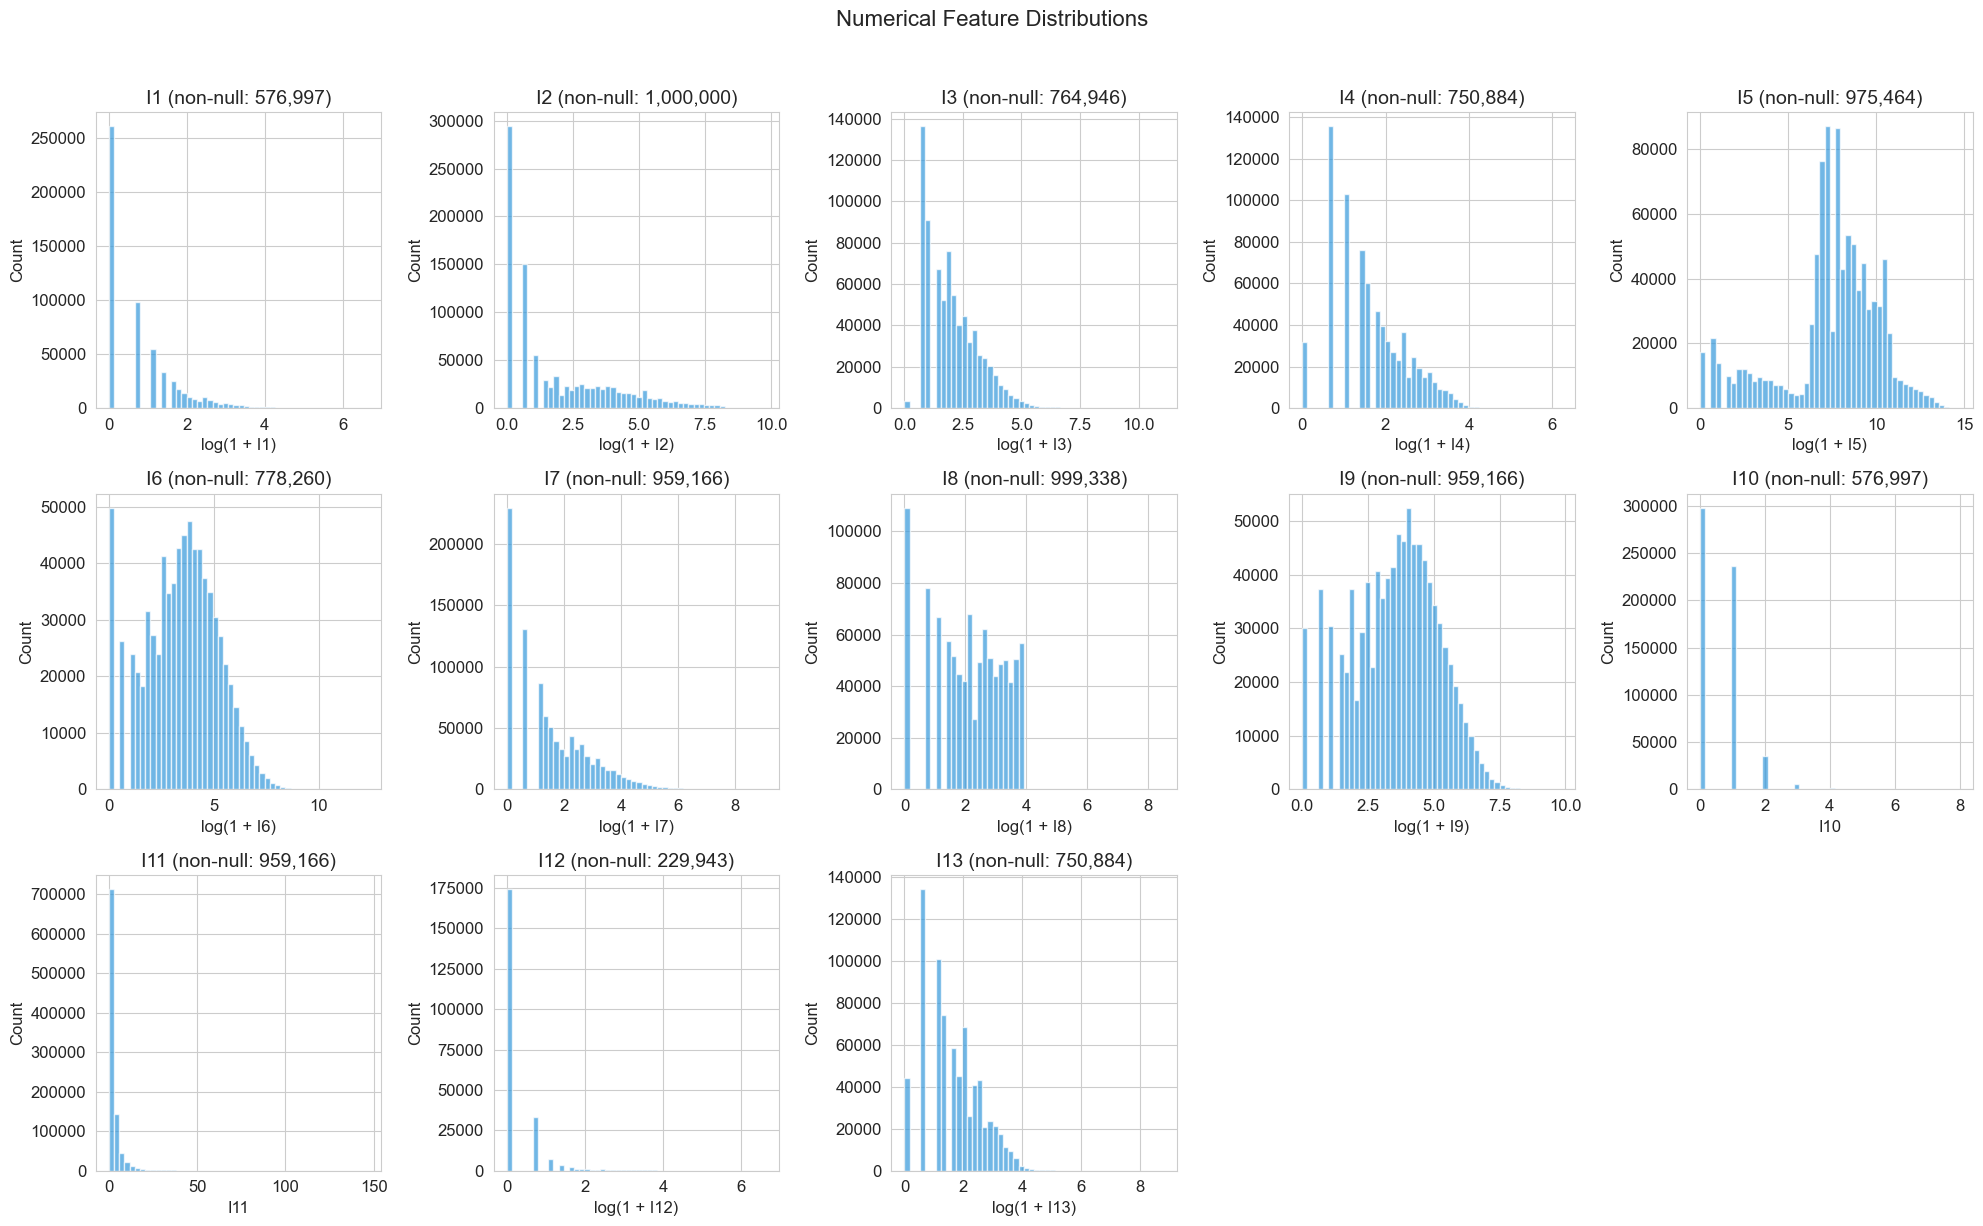

In [5]:
# Fig 2: Numerical feature distributions (3x5 grid, last 2 empty)
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(NUM_FEATURES):
    ax = axes[i]
    data = df[col].dropna()
    
    # Use log scale for highly skewed features
    if data.max() > 100 * (data.median() + 1):
        data_plot = np.log1p(data.clip(lower=0))
        ax.hist(data_plot, bins=50, color='#3498db', alpha=0.7, edgecolor='white')
        ax.set_xlabel(f'log(1 + {col})')
    else:
        ax.hist(data, bins=50, color='#3498db', alpha=0.7, edgecolor='white')
        ax.set_xlabel(col)
    
    ax.set_title(f'{col} (non-null: {len(data):,})')
    ax.set_ylabel('Count')

# Hide unused subplots
for j in range(len(NUM_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numerical Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('fig2_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Missing Value Analysis

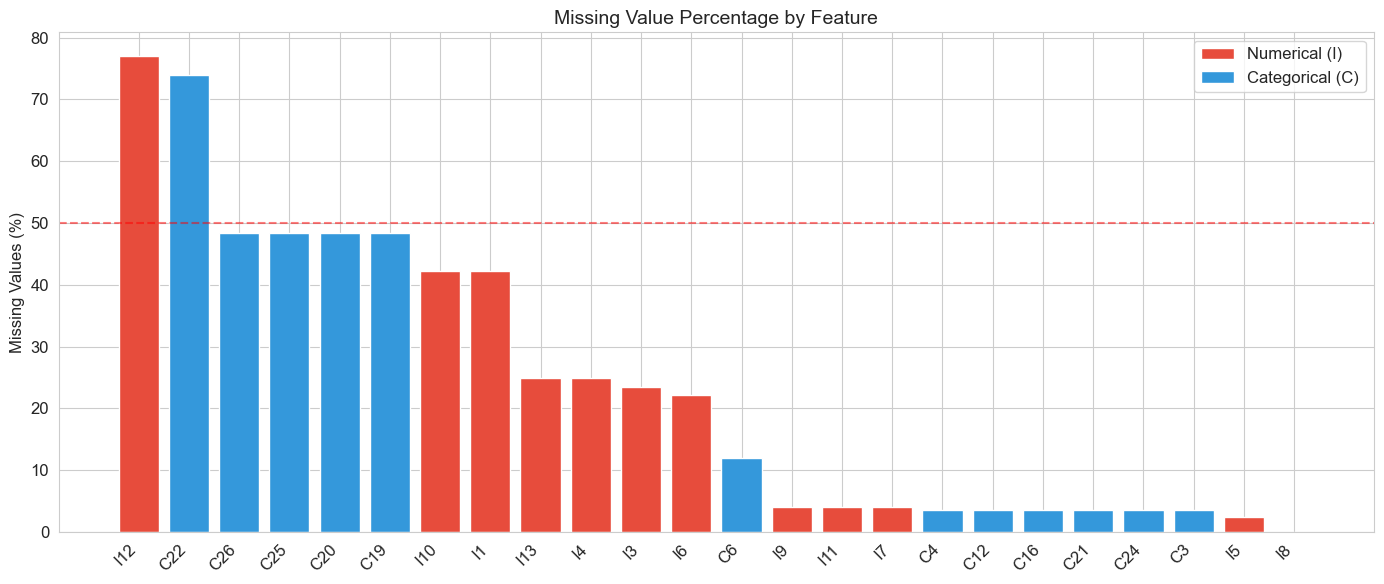

Missing value summary:
Numerical features with missing values: 12/13
Categorical features with missing values: 12/26


In [6]:
# Fig 3: Missing value % bar chart
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if 'I' in col else '#3498db' for col in missing_pct.index]
bars = ax.bar(range(len(missing_pct)), missing_pct.values, color=colors)
ax.set_xticks(range(len(missing_pct)))
ax.set_xticklabels(missing_pct.index, rotation=45, ha='right')
ax.set_ylabel('Missing Values (%)')
ax.set_title('Missing Value Percentage by Feature')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Numerical (I)'),
    Patch(facecolor='#3498db', label='Categorical (C)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('fig3_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print('Missing value summary:')
print(f'Numerical features with missing values: {df[NUM_FEATURES].isnull().any().sum()}/{len(NUM_FEATURES)}')
print(f'Categorical features with missing values: {df[CAT_FEATURES].isnull().any().sum()}/{len(CAT_FEATURES)}')

### 3.4 Categorical Feature Cardinality

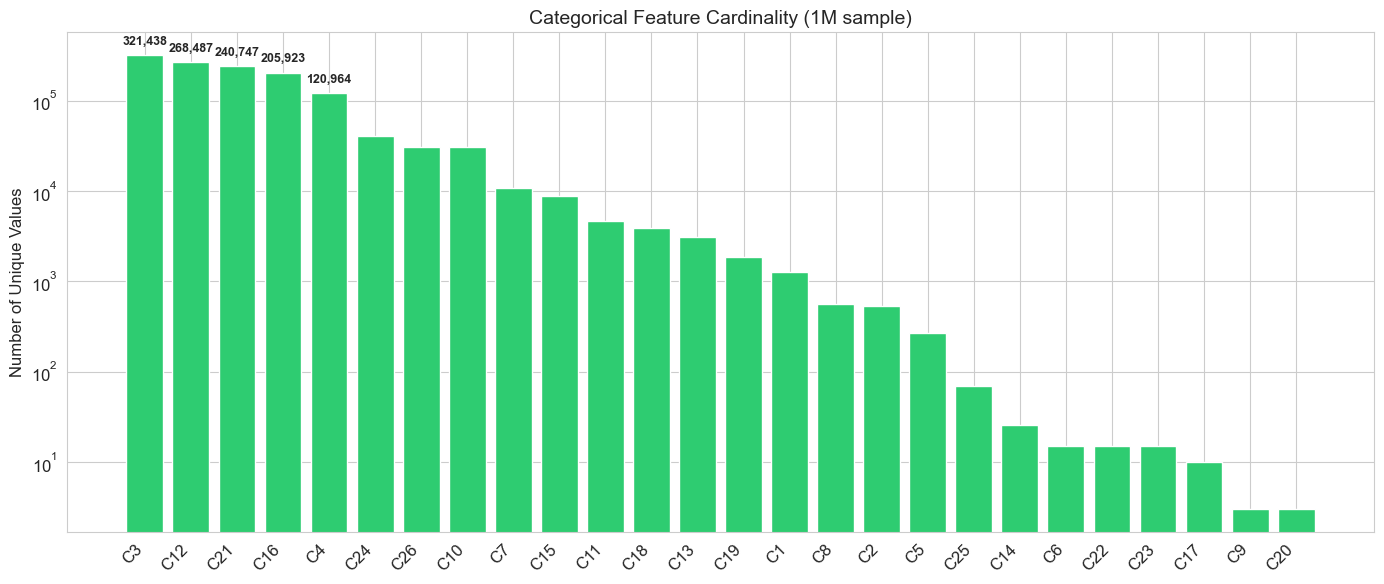

Cardinality summary:
Min cardinality: 3 (C9)
Max cardinality: 321,438 (C3)
Median cardinality: 2,461


In [7]:
# Fig 4: Categorical cardinality bar chart
cardinalities = {col: df[col].nunique() for col in CAT_FEATURES}
card_series = pd.Series(cardinalities).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(card_series)), card_series.values, color='#2ecc71', edgecolor='white')
ax.set_xticks(range(len(card_series)))
ax.set_xticklabels(card_series.index, rotation=45, ha='right')
ax.set_ylabel('Number of Unique Values')
ax.set_title('Categorical Feature Cardinality (1M sample)')
ax.set_yscale('log')

# Annotate top-5 highest cardinality
for i in range(min(5, len(card_series))):
    ax.text(i, card_series.values[i] * 1.3, f'{card_series.values[i]:,}',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_categorical_cardinality.png', dpi=150, bbox_inches='tight')
plt.show()

print('Cardinality summary:')
print(f'Min cardinality: {card_series.min():,} ({card_series.idxmin()})')
print(f'Max cardinality: {card_series.max():,} ({card_series.idxmax()})')
print(f'Median cardinality: {card_series.median():,.0f}')

> **Concept:** High-cardinality categorical features are a major challenge in CTR prediction.
> Features with hundreds of thousands of unique values cannot be efficiently one-hot encoded.
> This is exactly why embedding-based approaches (as used in DeepFM and DCN) are essential:
> they map each categorical value to a dense, low-dimensional vector.

### 3.5 Feature Correlation Analysis

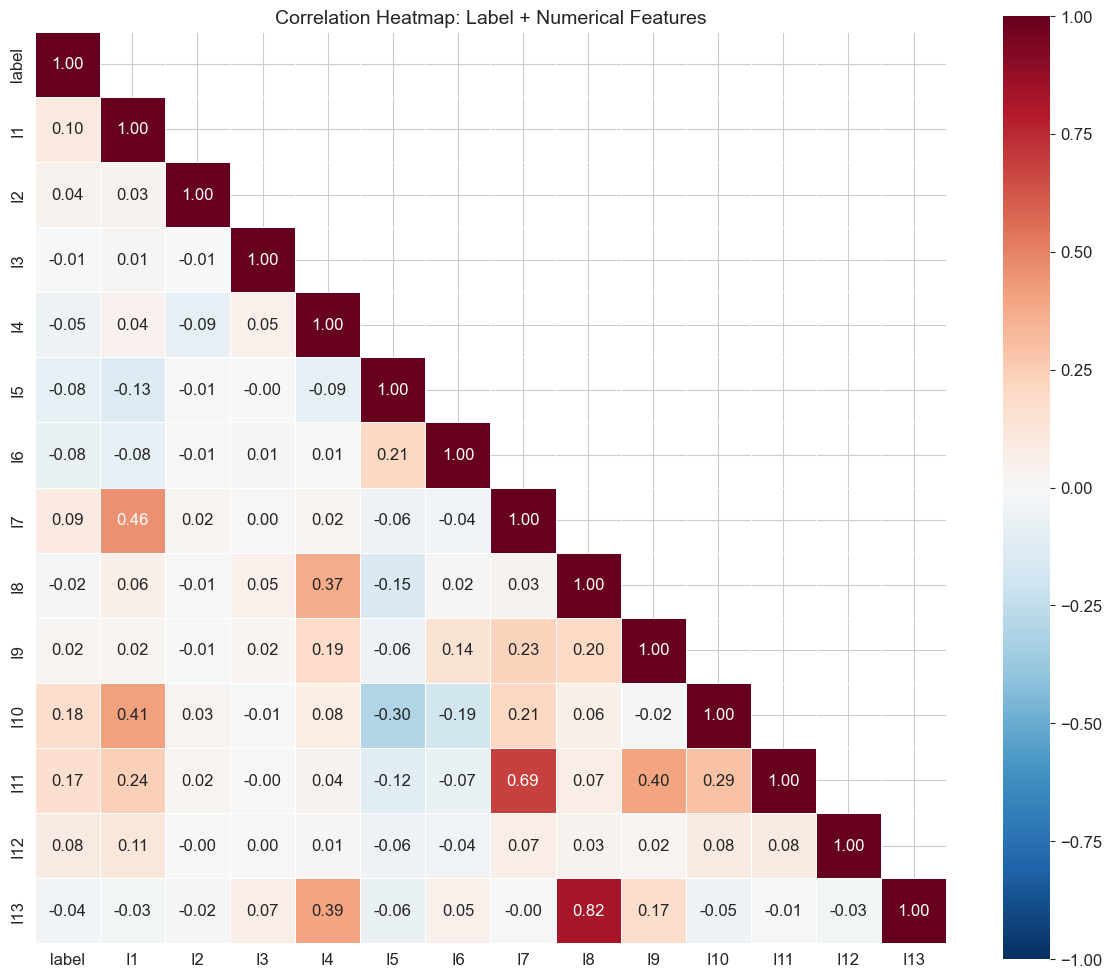

Top correlations with label:
  I10: 0.1793
  I11: 0.1704
  I1: 0.0987
  I7: 0.0922
  I5: 0.0843


In [8]:
# Fig 5: Correlation heatmap for numerical features
corr_cols = ['label'] + NUM_FEATURES
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1
)
ax.set_title('Correlation Heatmap: Label + Numerical Features')

plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Show top correlations with label
label_corr = corr_matrix['label'].drop('label').abs().sort_values(ascending=False)
print('Top correlations with label:')
for feat, corr in label_corr.head(5).items():
    print(f'  {feat}: {corr:.4f}')

### 3.6 Top-K Value Distributions for Categorical Features

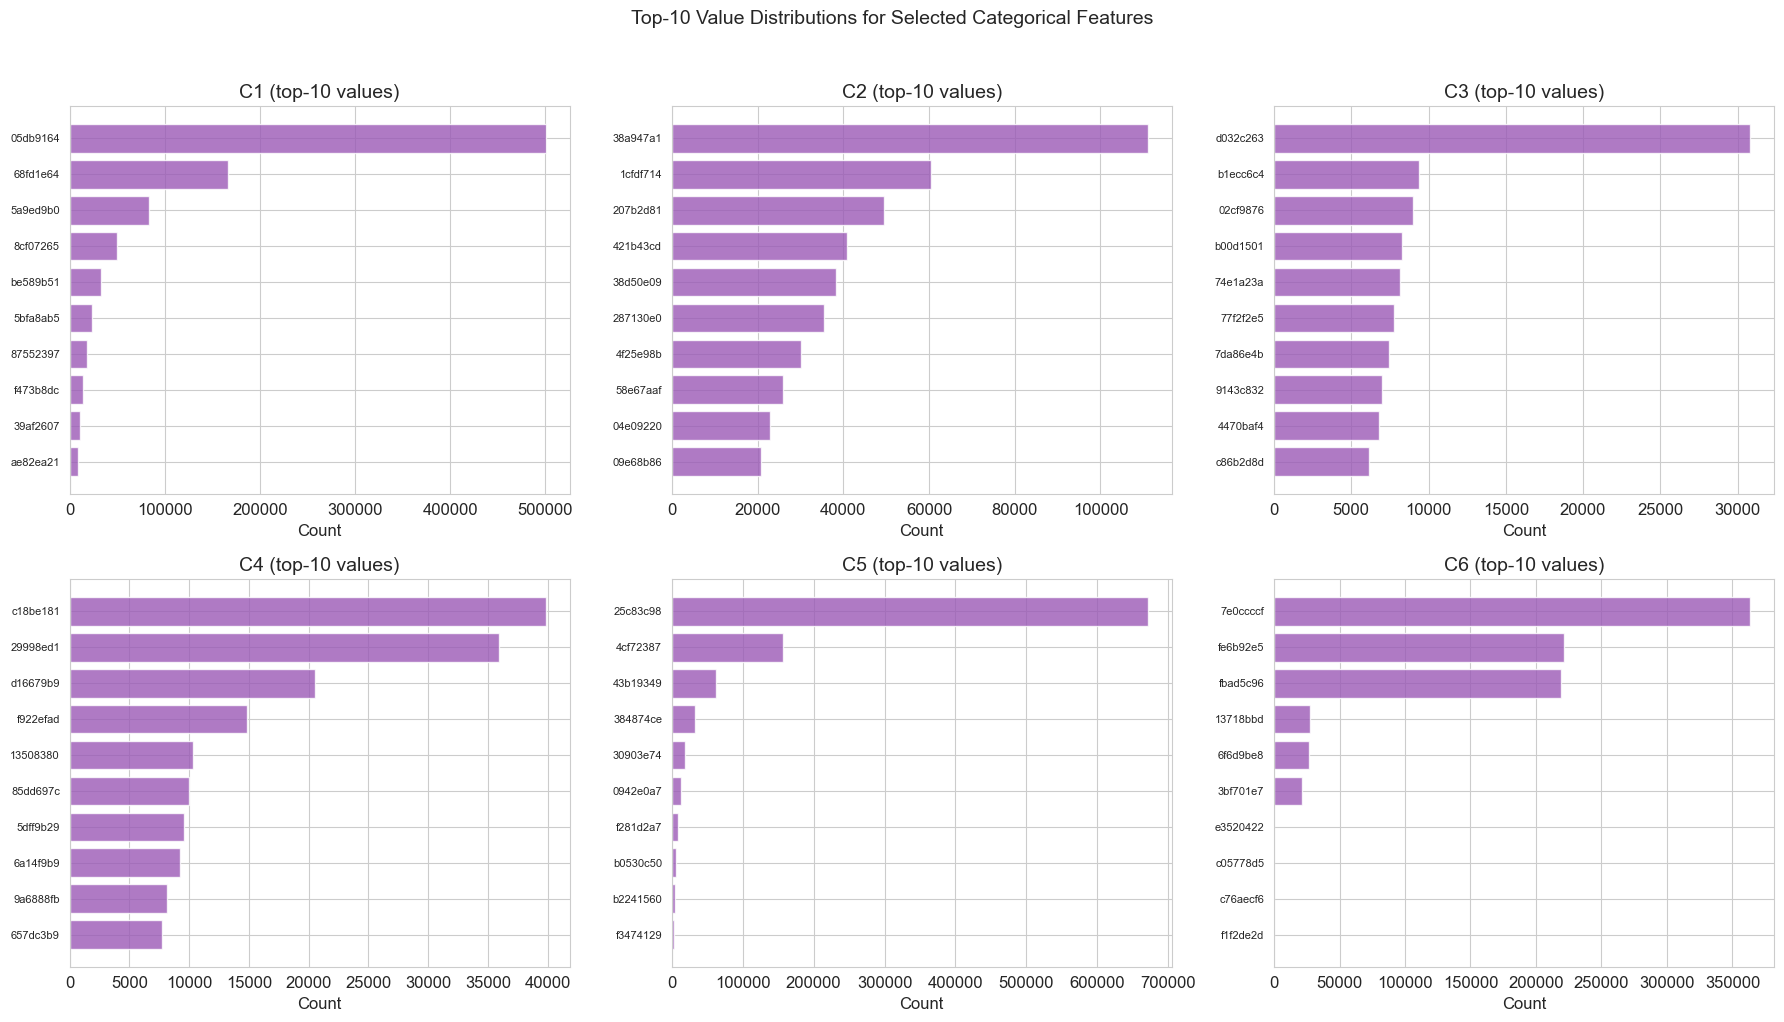

In [9]:
# Show top-10 value distributions for first 6 categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(CAT_FEATURES[:6]):
    ax = axes[i]
    top_values = df[col].value_counts().head(10)
    
    # Truncate long hex strings for display
    labels = [str(v)[:8] for v in top_values.index]
    ax.barh(range(len(top_values)), top_values.values, color='#9b59b6', alpha=0.8)
    ax.set_yticks(range(len(top_values)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Count')
    ax.set_title(f'{col} (top-10 values)')
    ax.invert_yaxis()

plt.suptitle('Top-10 Value Distributions for Selected Categorical Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

> **Concept:** Feature engineering for deep CTR models like DeepFM and DCN requires careful
> preprocessing. Unlike tree-based models, neural networks are sensitive to:
> - Missing values (need explicit handling)
> - Feature scale (numerical features should be normalized)
> - Feature distribution (log-transform helps with skewed features)
> - Categorical encoding (must be mapped to integer indices for embedding lookup)

### 4.1 Handle Missing Values

In [10]:
df_processed = df.copy()

# Fill numerical missing values with 0
# Rationale: In the Criteo dataset, missing numerical values often indicate
# that the feature is not applicable. Filling with 0 is standard practice.
for col in NUM_FEATURES:
    df_processed[col] = df_processed[col].fillna(0)

# Fill categorical missing values with "__MISSING__"
# Rationale: We treat missing as a separate category so the model can learn
# a dedicated embedding for the "missing" concept.
for col in CAT_FEATURES:
    df_processed[col] = df_processed[col].fillna('__MISSING__')

print('Missing values after filling:')
print(f'Total missing: {df_processed.isnull().sum().sum()}')

Missing values after filling:
Total missing: 0


### 4.2 Log-Transform Numerical Features

Many numerical features in Criteo are highly right-skewed. We apply the transformation:

$$x' = \log(x + 2)$$

The offset of 2 (instead of 1) handles the case where $x = 0$ more smoothly and
avoids $\log(1) = 0$ which would lose information.

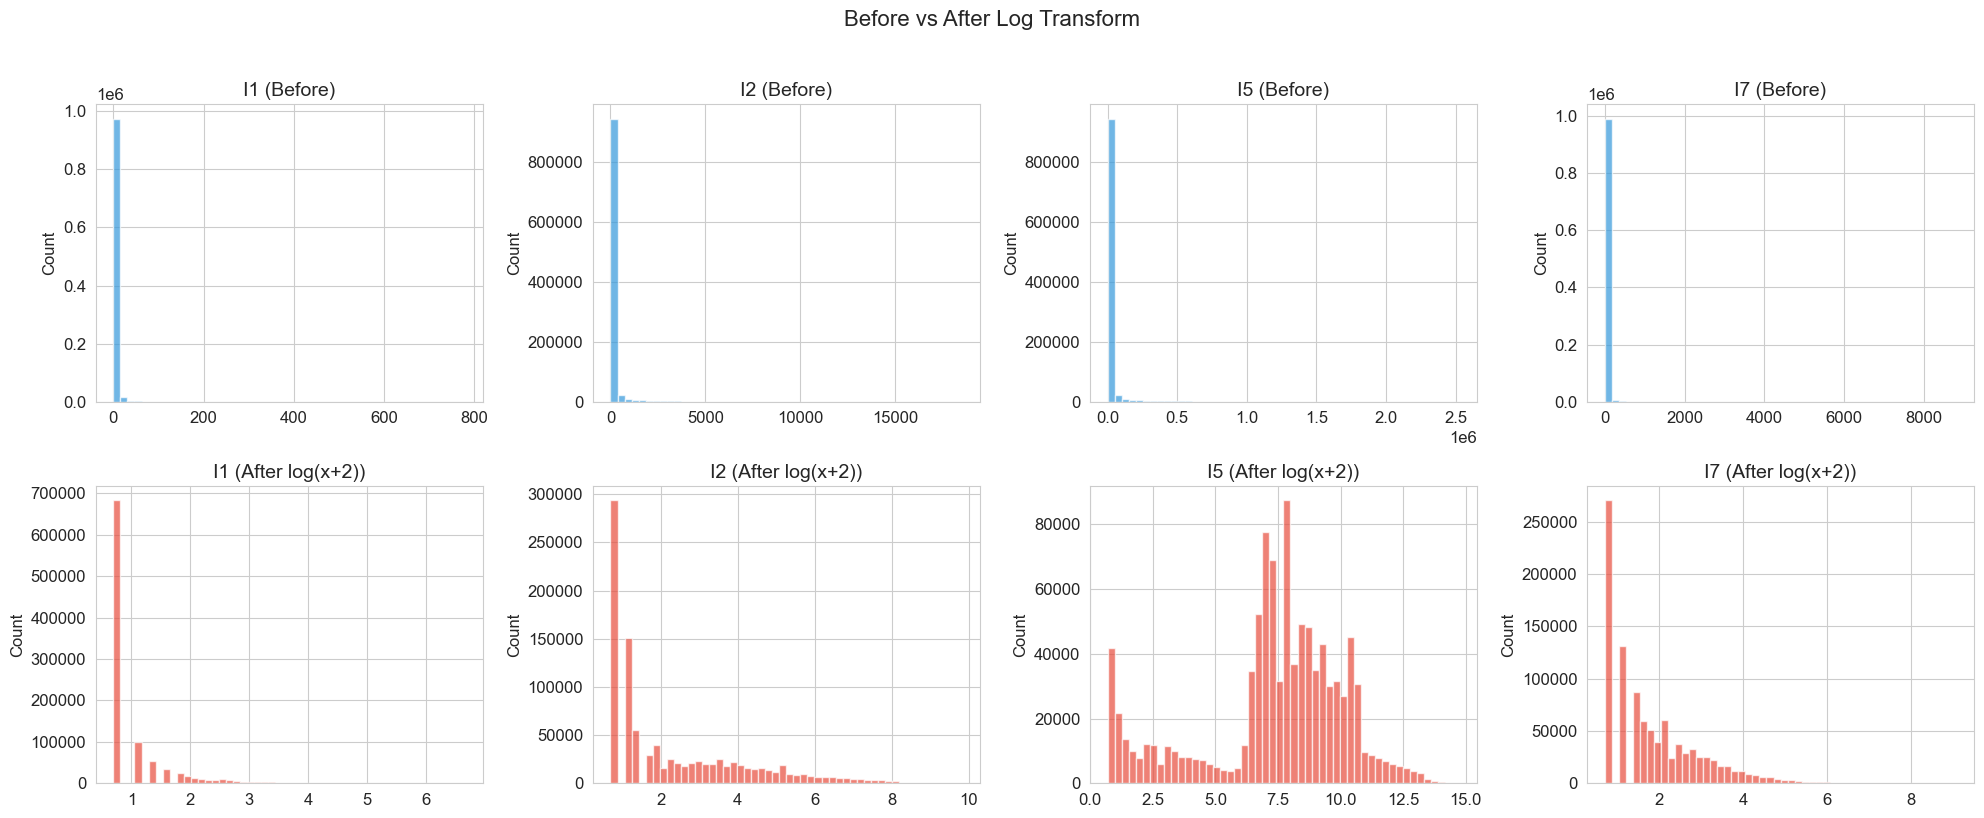

Numerical feature statistics after log transform:


,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13
count,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000,1000000.000
mean,1.023,2.336,1.846,1.596,7.324,2.889,1.826,2.283,3.513,0.820,1.260,0.736,1.593
std,0.622,1.841,1.087,0.819,2.880,1.837,1.130,0.977,1.586,0.215,0.570,0.230,0.845
min,0.693,0.693,0.693,0.693,0.693,0.693,0.693,0.693,0.693,0.693,0.693,0.693,0.693
25%,0.693,0.693,1.099,0.693,6.611,0.693,0.693,1.386,2.303,0.693,0.693,0.693,0.693
50%,0.693,1.386,1.609,1.386,7.804,2.890,1.609,2.303,3.638,0.693,1.099,0.693,1.386
75%,1.099,3.526,2.485,2.197,9.204,4.304,2.485,3.091,4.663,1.099,1.386,0.693,2.197
max,6.662,9.827,11.090,6.232,14.743,12.361,9.084,8.530,9.869,2.303,5.004,6.646,8.810


In [11]:
# Fig 6: Before/after log transform comparison
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Select 4 features to show before/after
show_features = ['I1', 'I2', 'I5', 'I7']

for i, col in enumerate(show_features):
    # Before
    data_before = df_processed[col].clip(lower=0)
    axes[0, i].hist(data_before, bins=50, color='#3498db', alpha=0.7, edgecolor='white')
    axes[0, i].set_title(f'{col} (Before)')
    axes[0, i].set_ylabel('Count')
    
    # After log transform
    data_after = np.log(data_before + 2)
    axes[1, i].hist(data_after, bins=50, color='#e74c3c', alpha=0.7, edgecolor='white')
    axes[1, i].set_title(f'{col} (After log(x+2))')
    axes[1, i].set_ylabel('Count')

plt.suptitle('Before vs After Log Transform', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('fig6_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()

# Apply log transform to all numerical features
for col in NUM_FEATURES:
    df_processed[col] = np.log(df_processed[col].clip(lower=0) + 2)

print('Numerical feature statistics after log transform:')
df_processed[NUM_FEATURES].describe().round(3)

> **Pro Tip:** The `log(x + 2)` transform is preferred over `log(x + 1)` for the Criteo
> dataset because many features have a large number of zeros. With `log(x + 1)`, zeros
> map to `log(1) = 0`, making them indistinguishable from the fill value. Using `log(x + 2)`
> maps zeros to `log(2) ≈ 0.693`, preserving the distinction.

### 4.3 Label-Encode Categorical Features

In [12]:
# For high-cardinality features, keep only top-K most frequent values
# and map all rare values to a single "__RARE__" bucket
TOP_K = 10000

label_encoders = {}
cat_cardinalities = {}  # Store cardinality for each feature (needed for embedding layers)

for col in CAT_FEATURES:
    # Count value frequencies
    value_counts = df_processed[col].value_counts()
    
    # Keep top-K values, map rest to __RARE__
    if len(value_counts) > TOP_K:
        top_values = set(value_counts.head(TOP_K).index)
        df_processed[col] = df_processed[col].apply(
            lambda x: x if x in top_values else '__RARE__'
        )
    
    # Label encode
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    cat_cardinalities[col] = len(le.classes_)

print('Categorical feature cardinalities after processing:')
for col, card in sorted(cat_cardinalities.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'  {col}: {card:,}')
print(f'  ...')
print(f'Total categorical features: {len(CAT_FEATURES)}')
print(f'Total unique categories: {sum(cat_cardinalities.values()):,}')

Categorical feature cardinalities after processing:
  C3: 10,001
  C4: 10,001
  C7: 10,001
  C10: 10,001
  C12: 10,001
  C16: 10,001
  C21: 10,001
  C24: 10,001
  C26: 10,001
  C15: 8,934
  ...
Total categorical features: 26
Total unique categories: 115,260


> **Common Pitfall:** When clipping categorical features to top-K values, you must ensure
> the `__RARE__` bucket is applied consistently between training and inference. If a new
> category appears at inference time, it should also map to `__RARE__`. Save your
> label encoders and top-K mappings!

### 4.4 Compute Embedding Dimensions

In [13]:
# Embedding dimension heuristic: min(16, max(4, int(log2(cardinality))))
embedding_dims = {}
for col, card in cat_cardinalities.items():
    embedding_dims[col] = min(16, max(4, int(np.log2(card))))

print('Embedding dimensions per feature:')
for col in CAT_FEATURES:
    print(f'  {col}: cardinality={cat_cardinalities[col]:>6,} -> emb_dim={embedding_dims[col]}')

Embedding dimensions per feature:
  C1: cardinality= 1,261 -> emb_dim=10
  C2: cardinality=   531 -> emb_dim=9
  C3: cardinality=10,001 -> emb_dim=13
  C4: cardinality=10,001 -> emb_dim=13
  C5: cardinality=   267 -> emb_dim=8
  C6: cardinality=    16 -> emb_dim=4
  C7: cardinality=10,001 -> emb_dim=13
  C8: cardinality=   563 -> emb_dim=9
  C9: cardinality=     3 -> emb_dim=4
  C10: cardinality=10,001 -> emb_dim=13
  C11: cardinality= 4,731 -> emb_dim=12
  C12: cardinality=10,001 -> emb_dim=13
  C13: cardinality= 3,068 -> emb_dim=11
  C14: cardinality=    26 -> emb_dim=4
  C15: cardinality= 8,934 -> emb_dim=13
  C16: cardinality=10,001 -> emb_dim=13
  C17: cardinality=    10 -> emb_dim=4
  C18: cardinality= 3,881 -> emb_dim=11
  C19: cardinality= 1,855 -> emb_dim=10
  C20: cardinality=     4 -> emb_dim=4
  C21: cardinality=10,001 -> emb_dim=13
  C22: cardinality=    16 -> emb_dim=4
  C23: cardinality=    15 -> emb_dim=4
  C24: cardinality=10,001 -> emb_dim=13
  C25: cardinality=    70

### 4.5 Feature Importance (Logistic Regression Baseline)

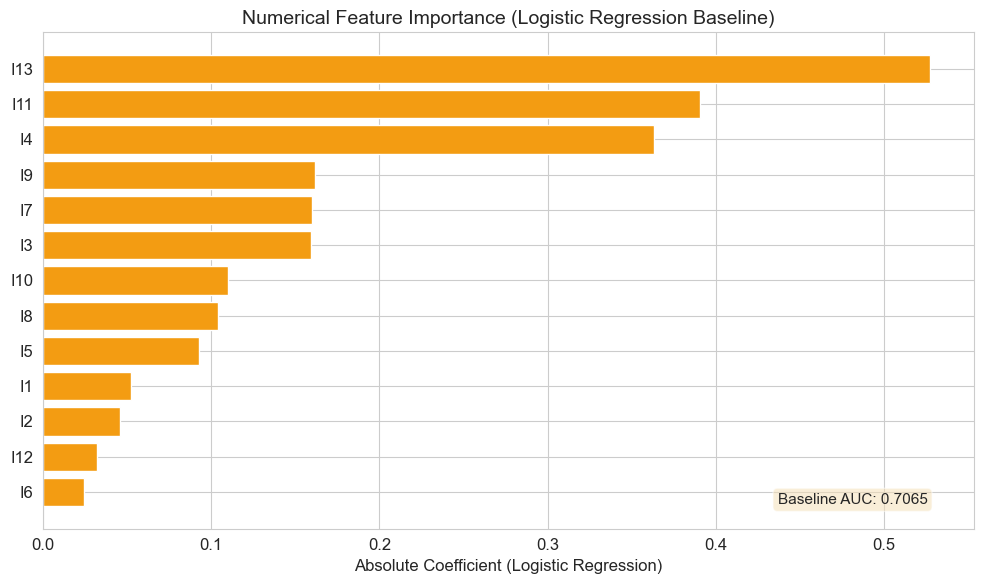

Logistic Regression baseline (numerical features only):
  AUC: 0.7065


  LogLoss: 0.5172


In [14]:
# Fig 7: Feature importance from logistic regression on numerical features
X_num = df_processed[NUM_FEATURES].values
y = df_processed['label'].values

# Standardize for logistic regression
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

# Train simple logistic regression
lr = LogisticRegression(max_iter=100, random_state=SEED, solver='lbfgs')
lr.fit(X_num_scaled, y)

# Feature importance (absolute coefficient values)
importance = np.abs(lr.coef_[0])
importance_df = pd.DataFrame({
    'feature': NUM_FEATURES,
    'importance': importance
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df['feature'], importance_df['importance'], color='#f39c12', edgecolor='white')
ax.set_xlabel('Absolute Coefficient (Logistic Regression)')
ax.set_title('Numerical Feature Importance (Logistic Regression Baseline)')

# Add AUC score
y_pred_proba = lr.predict_proba(X_num_scaled)[:, 1]
baseline_auc = roc_auc_score(y, y_pred_proba)
ax.text(0.95, 0.05, f'Baseline AUC: {baseline_auc:.4f}',
        transform=ax.transAxes, ha='right', fontsize=11,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('fig7_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Logistic Regression baseline (numerical features only):')
print(f'  AUC: {baseline_auc:.4f}')
print(f'  LogLoss: {log_loss(y, y_pred_proba):.4f}')

## 5. Save Processed Data

We save the processed DataFrame and all metadata needed by downstream notebooks.

In [15]:
# Train/test split (80/20)
train_df, test_df = train_test_split(
    df_processed, test_size=0.2, random_state=SEED, stratify=df_processed['label']
)

print(f'Train set: {len(train_df):,} samples (CTR: {train_df["label"].mean():.4f})')
print(f'Test set:  {len(test_df):,} samples (CTR: {test_df["label"].mean():.4f})')

# Save train/test DataFrames
train_df.to_parquet(os.path.join(PROCESSED_DIR, 'train.parquet'), index=False)
test_df.to_parquet(os.path.join(PROCESSED_DIR, 'test.parquet'), index=False)

# Save metadata
metadata = {
    'num_features': NUM_FEATURES,
    'cat_features': CAT_FEATURES,
    'cat_cardinalities': cat_cardinalities,
    'embedding_dims': embedding_dims,
    'label_encoders': label_encoders,
    'top_k': TOP_K,
    'sample_size': SAMPLE_SIZE,
    'seed': SEED
}

with open(os.path.join(PROCESSED_DIR, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)

print(f'\nSaved to {PROCESSED_DIR}:')
for fname in os.listdir(PROCESSED_DIR):
    fpath = os.path.join(PROCESSED_DIR, fname)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f'  {fname}: {size_mb:.1f} MB')

Train set: 800,000 samples (CTR: 0.2549)
Test set:  200,000 samples (CTR: 0.2550)



Saved to ../../data/criteo/processed:
  metadata.pkl: 1.3 MB
  test.parquet: 9.0 MB
  train.parquet: 35.1 MB


## 6. Exercises

### Exercise 1: Analyze CTR by Feature Bins

Bin a numerical feature (e.g., I1) into 10 quantile buckets and compute the CTR for each bin. Plot the result. What does this tell you about the feature's predictive power?

In [16]:
# Exercise 1: Analyze CTR by Feature Bins
# 
# The idea: split a numerical feature into 10 equal-sized groups (quantiles),
# then see what the click-through rate is in each group.
# If CTR changes across bins, the feature is predictive.

# Step 1: Bin I1 into 10 quantile buckets
# pd.qcut splits data so each bucket has ~equal number of samples
# e.g., bucket 1 = lowest 10% of I1 values, bucket 10 = highest 10%
df_processed['I1_bin'] = pd.qcut(df_processed['I1'], q=10, duplicates='drop')

# Step 2: Group by bin, compute mean CTR per bin
ctr_by_bin = df_processed.groupby('I1_bin', observed=True)['label'].agg(['mean', 'count'])
ctr_by_bin.columns = ['CTR', 'Count']

print("CTR by I1 quantile bin:")
print(ctr_by_bin.to_string())
print(f"
Overall CTR: {df_processed['label'].mean():.4f}")

# Step 3: Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart of CTR per bin
x = range(len(ctr_by_bin))
bars = ax1.bar(x, ctr_by_bin['CTR'], color='#3498db', edgecolor='white', alpha=0.8)
ax1.set_xlabel('I1 Quantile Bin (low → high)')
ax1.set_ylabel('Click-Through Rate', color='#3498db')
ax1.set_xticks(x)
ax1.set_xticklabels([f'Q{i+1}' for i in x], fontsize=10)

# Add overall CTR reference line
ax1.axhline(y=df_processed['label'].mean(), color='red', linestyle='--', 
            alpha=0.7, label=f"Overall CTR ({df_processed['label'].mean():.4f})")

# Overlay sample count on secondary axis
ax2 = ax1.twinx()
ax2.plot(x, ctr_by_bin['Count'], 'o-', color='#e67e22', alpha=0.7, label='Sample count')
ax2.set_ylabel('Sample Count', color='#e67e22')

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.set_title('CTR by I1 Quantile Bin — Does I1 predict clicks?')
plt.tight_layout()
plt.savefig('exercise1_ctr_by_bin.png', dpi=150, bbox_inches='tight')
plt.show()

# Step 4: Discussion
ctr_range = ctr_by_bin['CTR'].max() - ctr_by_bin['CTR'].min()
print(f"
CTR range across bins: {ctr_range:.4f}")
print(f"If CTR varies a lot across bins, I1 is a strong predictor.")
print(f"If CTR is flat (~{df_processed['label'].mean():.4f} everywhere), I1 is weak.")

# Check monotonicity
diffs = ctr_by_bin['CTR'].diff().dropna()
if (diffs > 0).all():
    print("Relationship is monotonically INCREASING (higher I1 → more clicks)")
elif (diffs < 0).all():
    print("Relationship is monotonically DECREASING (higher I1 → fewer clicks)")
else:
    print("Relationship is NON-monotonic (CTR goes up and down across bins)")
    print("This means a linear model can't fully capture I1's effect — need nonlinear models!")

# Clean up temp column
df_processed.drop('I1_bin', axis=1, inplace=True)


### Exercise 2: Cross-Feature Analysis

Select two categorical features with moderate cardinality (e.g., C1 and C2). Create a cross-tabulation of their top-5 values and compute the CTR for each combination. This motivates why feature crossing is valuable.

In [17]:
# TODO: Exercise 2
# 1. Select top-5 values of C1 and C2
# 2. Filter the DataFrame to rows containing only these values
# 3. Create a pivot table with CTR as values
# 4. Visualize as a heatmap
# 5. Discuss: do certain combinations have unusually high/low CTR?

# Your code here:
pass

### Exercise 3: Alternative Missing Value Strategies

Compare different missing value imputation strategies for numerical features: fill with 0, fill with mean, fill with median. Which gives the best logistic regression AUC?

In [18]:
# TODO: Exercise 3
# 1. Create 3 copies of the raw numerical data
# 2. Apply different fill strategies: 0, mean, median
# 3. Apply log(x+2) transform to each
# 4. Train logistic regression on each
# 5. Compare AUC scores

# Your code here:
pass

### Exercise 4: Embedding Dimension Analysis

Plot the relationship between feature cardinality and the heuristic embedding dimension. Try a different formula (e.g., `min(50, 1 + int(cardinality**0.25))`) and compare the total number of embedding parameters.

In [19]:
# TODO: Exercise 4
# 1. Compute embedding dims with the original formula
# 2. Compute embedding dims with the alternative formula
# 3. Calculate total parameters: sum(cardinality * emb_dim) for each
# 4. Plot a scatter chart: cardinality vs emb_dim for both formulas
# 5. Discuss the tradeoff between model capacity and efficiency

# Your code here:
pass

## 7. Summary & Key Takeaways

In this notebook, we explored the Criteo Display Advertising Challenge dataset and prepared
it for training deep feature crossing models.

### Key Findings

1. **Class Balance:** The dataset has a CTR of roughly 26%, which is relatively balanced
   for a CTR dataset but still requires careful metric selection (AUC, LogLoss).

2. **Missing Values:** Many features have significant missing rates. We handle this by
   filling numerical features with 0 and categorical features with a dedicated `__MISSING__` token.

3. **Skewed Distributions:** Numerical features are highly right-skewed, motivating the
   $\log(x + 2)$ transformation.

4. **High Cardinality:** Categorical features have cardinalities ranging from tens to
   hundreds of thousands. We clip to top-10K values and use embedding layers.

5. **Feature Interactions:** The correlation analysis hints at complex feature interactions
   that motivate explicit feature crossing in models like DeepFM and DCN.

### Next Steps

In the next notebook, we will implement **DeepFM**, which combines Factorization Machines
with deep neural networks to capture both low-order and high-order feature interactions.